In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split
from torchvision.models import resnet18, ResNet18_Weights
import torchvision.models as models
import torch.nn as nn
import time

In [2]:
# Transform the images
data_statictics = ((0.5,0.5,0.5), (0.5,0.5,0.5))

transformed_train_images = transforms.Compose([
    transforms.RandomCrop(32, padding=4, padding_mode='reflect'),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(), #CxHxW
    transforms.Normalize(*data_statictics, inplace=True), #[-1, 1]
])

transformed_test_images = transforms.Compose([
    transforms.ToTensor(), #CxHxW
    transforms.Normalize(*data_statictics, inplace=True), #[-1, 1]
])

In [3]:
# train dataset
train_dataset = torchvision.datasets.CIFAR10(
    root="../data/downloads", 
    download=True,
    train=True,
    transform=transformed_train_images
)

# validation split
total_size = len(train_dataset)
val_size = int(0.2 * total_size)
train_size = total_size - val_size 

train_split, val_split = random_split(
    train_dataset,
    [train_size,val_size]
)

val_dataset = torchvision.datasets.CIFAR10(
    root="../data/downloads",
    train=True,
    download=False,
    transform=transformed_test_images,
)

val_split = torch.utils.data.Subset(
    val_dataset,
    val_split.indices,
)

# test dataset
test_dataset = torchvision.datasets.CIFAR10(
    root="../data/downloads", 
    download=True,
    train=False,
    transform=transformed_test_images
)

train_dataloader = torch.utils.data.DataLoader(
    dataset=train_split,
    batch_size=16,
    shuffle=True,
    pin_memory=True
)

val_dataloader = torch.utils.data.DataLoader(
    dataset=val_split,
    batch_size=16,
    shuffle=False,
    pin_memory=True
)

test_dataloader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=16,
    pin_memory=True
)

In [4]:
# device selection
if not torch.cuda.is_available():
    raise RuntimeError("CUDA is unavailable in this notebook environment.")

device = torch.device("cuda:0")
# Load ResNet-18 with pre-trained ImageNet weights
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

In [5]:
# Extract the number of input features going into the final layer
num_features = model.fc.in_features

# Replace the final layer with a new one matching CIFAR-10 (10 classes)
model.fc = nn.Linear(num_features, 10)

# Optimize for 32x32 images
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model.maxpool = nn.Identity()

model = model.to(device)

# Fine tuning the entire network using very low LR
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4) 

# criterion
criterion = nn.CrossEntropyLoss()

print("GPU:", torch.cuda.get_device_name(device))
print("Model device:", next(model.parameters()).device)
print("PyTorch:", torch.__version__)
print("PyTorch CUDA version:", torch.version.cuda)

GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Model device: cuda:0
PyTorch: 2.14.0+cu130
PyTorch CUDA version: 13.0


In [6]:
epochs = 5
best_val_loss = float("inf")

for epoch in range(epochs):
    train_losses = []  # Changed name slightly to avoid confusion
    val_losses = []

    torch.cuda.synchronize(device)
    torch.cuda.reset_peak_memory_stats(device)
    epoch_start = time.perf_counter()

    # Train
    model.train() # Tell model it is training (fixes batchnorm)
    for images, labels in train_dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        
        optimizer.step() 

        train_losses.append(loss.item()) 

    avg_train_loss = sum(train_losses) / len(train_dataloader)    

    # Validation
    model.eval()
    with torch.no_grad():
        for images, labels in val_dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_losses.append(loss.item()) 

    avg_val_loss = sum(val_losses) / len(val_dataloader)

    torch.cuda.synchronize(device)
    epoch_seconds = time.perf_counter() - epoch_start
    peak_memory_mb = torch.cuda.max_memory_allocated(device) / (1024 ** 2)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"| Train loss: {avg_train_loss:.4f} "
        f"| Val loss: {avg_val_loss:.4f} "
        f"| Train + val time: {epoch_seconds:.2f}s "
        f"| Peak tensor memory: {peak_memory_mb:.1f} MiB"
    )

    # Save
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "../models/resnet18_cifar10_best.pth")


Epoch [1/5] | Train loss: 0.8205 | Val loss: 0.4401 | Train + val time: 66.55s | Peak tensor memory: 266.6 MiB
Epoch [2/5] | Train loss: 0.4809 | Val loss: 0.3320 | Train + val time: 66.20s | Peak tensor memory: 266.6 MiB
Epoch [3/5] | Train loss: 0.3795 | Val loss: 0.2975 | Train + val time: 68.15s | Peak tensor memory: 266.6 MiB
Epoch [4/5] | Train loss: 0.3088 | Val loss: 0.2617 | Train + val time: 65.67s | Peak tensor memory: 266.6 MiB
Epoch [5/5] | Train loss: 0.2679 | Val loss: 0.2443 | Train + val time: 67.17s | Peak tensor memory: 266.6 MiB


In [7]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# 2. Re-create the exact optimized model architecture
test_model = models.resnet18()
num_features = test_model.fc.in_features
test_model.fc = nn.Linear(num_features, 10)
test_model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
test_model.maxpool = nn.Identity()

# 3. Load your best saved weights and send model to your hardware device
test_model.load_state_dict(torch.load("../models/resnet18_cifar10_best.pth", map_location=device))
test_model = test_model.to(device)

# 4. Set to evaluation mode
test_model.eval()

# Trackers for global and per-class metrics
correct = 0
total = 0
class_correct = [0] * 10
class_total = [0] * 10

# 5. Run the evaluation loop (no gradient tracking needed)
with torch.no_grad():
    for images, labels in test_dataloader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = test_model(images)
        _, predicted = torch.max(outputs, 1)
        
        # Calculate global accuracy components
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Calculate per-class accuracy components
        for i in range(len(labels)):
            label = labels[i].item()
            pred = predicted[i].item()
            if label == pred:
                class_correct[label] += 1
            class_total[label] += 1

# 6. Print overall diagnostic performance
overall_acc = (correct / total) * 100
print(f"==========================================")
print(f"OVERALL TEST ACCURACY: {overall_acc:.2f}%")
print(f"==========================================\nPer-Class Breakdown:")

# Print breakdown of how well it handles each specific object type
for i in range(10):
    if class_total[i] > 0:
        class_acc = (class_correct[i] / class_total[i]) * 100
        print(f" - Accuracy of {classes[i]:<10}: {class_acc:.2f}%")
    else:
        print(f" - Accuracy of {classes[i]:<10}: No samples found")

OVERALL TEST ACCURACY: 90.97%
Per-Class Breakdown:
 - Accuracy of plane     : 91.90%
 - Accuracy of car       : 95.60%
 - Accuracy of bird      : 90.50%
 - Accuracy of cat       : 80.30%
 - Accuracy of deer      : 87.10%
 - Accuracy of dog       : 88.90%
 - Accuracy of frog      : 92.70%
 - Accuracy of horse     : 94.50%
 - Accuracy of ship      : 92.40%
 - Accuracy of truck     : 95.80%


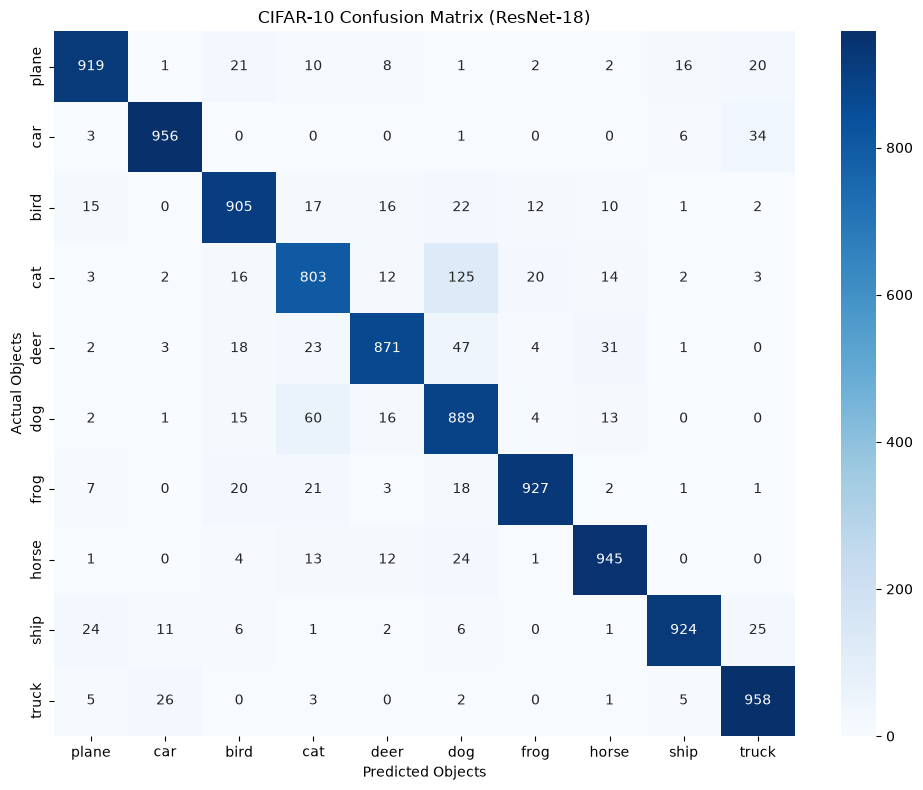

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Collect all true labels and predictions from the test set
all_preds = []
all_labels = []

test_model.eval()
with torch.no_grad():
    for images, labels in test_dataloader:
        images = images.to(device)
        outputs = test_model(images)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# 2. Compute the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# 3. Create the Seaborn Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True,          # Show raw numbers inside boxes
    fmt='d',             # Integer format
    cmap='Blues',        # Blue color scale
    xticklabels=classes, 
    yticklabels=classes
)

plt.xlabel('Predicted Objects')
plt.ylabel('Actual Objects')
plt.title('CIFAR-10 Confusion Matrix (ResNet-18)')
plt.tight_layout()
plt.show()
